# Phase 2: Data Acquisition and Preprocessing

In this section, I detail the steps involved in data acquisition, cleaning, exploratory data analysis (EDA), and preprocessing for the heart disease dataset. The dataset is sourced from Kaggle ([Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)) and provided in CSV format. This phase lays the groundwork for subsequent modeling by ensuring data integrity and preparing the features appropriately.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)

## Data Loading

The first step is to load the heart disease dataset from the provided CSV file. We then display the first few rows to obtain an initial view of the dataset.

In [2]:
# Load the dataset from the CSV file
df = pd.read_csv('heart.csv')

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Dataset Overview

Next, we examine the structure of the dataset by reviewing its shape, data types, and summary statistics. This helps in identifying the presence of any anomalies or irregularities.

In [3]:
# Display the dataset shape
print("Dataset shape:", df.shape)

# Display information about the dataset (data types, non-null counts)
print("\nDataset info:")
df.info()

# Display summary statistics for numerical features
print("\nSummary statistics:")
display(df.describe())

Dataset shape: (1025, 14)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Summary statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Missing Values and Duplicates

It is essential to check for missing values and duplicate entries in the dataset. Addressing these issues is crucial to ensure the integrity of the data before further processing.

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Check for duplicate rows in the dataset
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Number of duplicate rows: 723


## Data Cleaning

Since no missing values were detected, the next step is to remove any duplicate entries if present. This ensures that the dataset used for modeling is free from redundancy.

In [5]:
# Remove duplicates if any exist
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New dataset shape:", df.shape)
else:
    print("No duplicates found.")

Duplicates removed. New dataset shape: (302, 14)


## Exploratory Data Analysis (EDA)

To understand the underlying distributions and potential anomalies in the data, I generate histograms for each feature. This visual inspection assists in identifying skewness and outliers that might affect model performance.

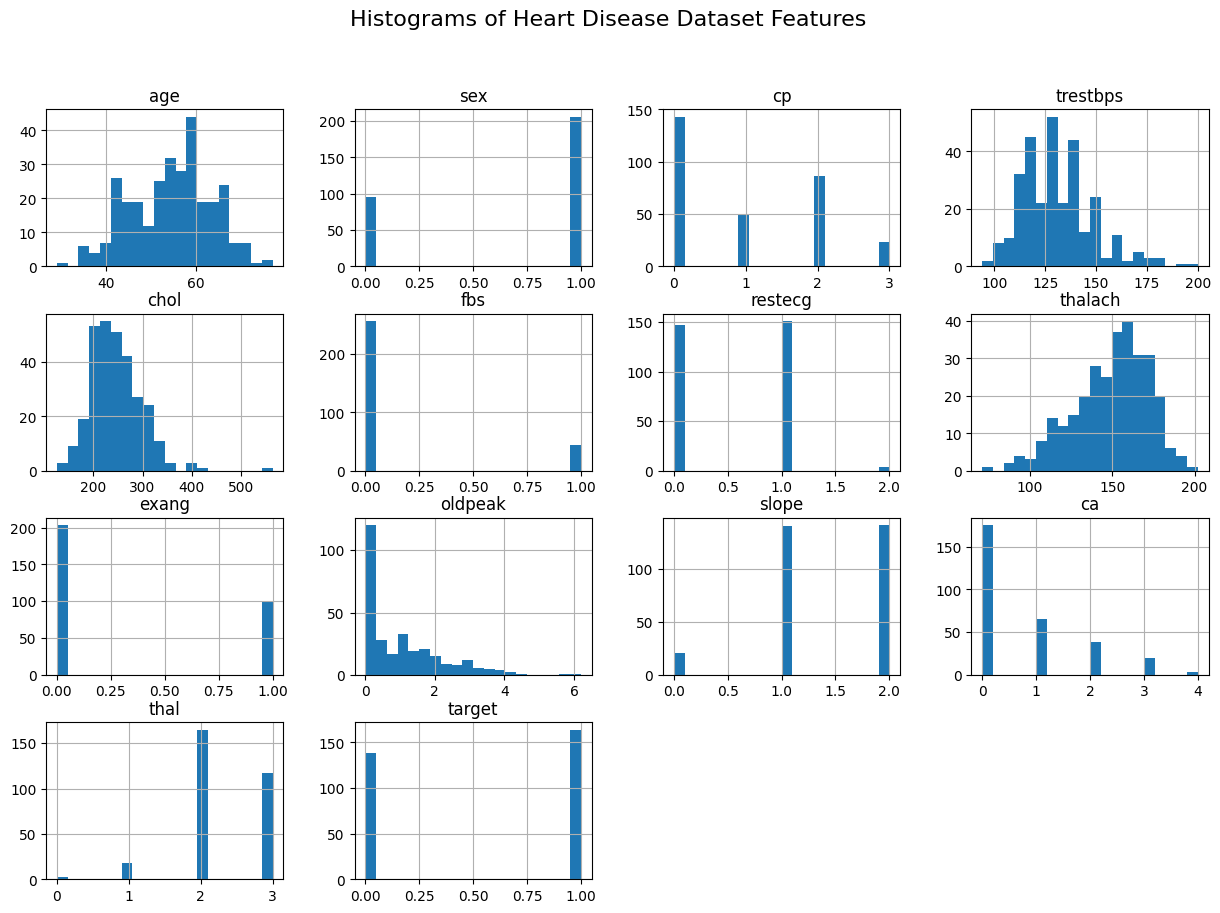

In [6]:
# Generate histograms for all features in the dataset
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Heart Disease Dataset Features", fontsize=16)
plt.show()

## Data Normalization and Feature Engineering

Standardizing numerical features can significantly enhance model performance by ensuring that each feature contributes equally. In this step, I employ the StandardScaler to normalize the features. If the dataset includes a target variable (commonly labeled as 'target'), it will be separated prior to scaling.

In [7]:
# List the columns in the dataset
print("Columns in the dataset:", df.columns.tolist())

# If the 'target' column is present, separate features and target
if 'target' in df.columns:
    features = df.drop('target', axis=1)
    target = df['target']
else:
    features = df.copy()

# Apply standardization to the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert the scaled features back to a DataFrame with original column names
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

print("Standardization complete. Displaying the first 5 rows of the scaled features:")
display(features_scaled_df.head())

Columns in the dataset: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Standardization complete. Displaying the first 5 rows of the scaled features:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994


## Final Preprocessed Dataset

The data has now been cleaned and standardized. If a target variable is present, it is reattached to the standardized feature set. The preprocessed dataset is now ready for the model development phase.

In [8]:
# Reattach the target variable if it exists
if 'target' in df.columns:
    preprocessed_df = pd.concat([features_scaled_df, target.reset_index(drop=True)], axis=1)
else:
    preprocessed_df = features_scaled_df.copy()

# Display the shape and a preview of the final dataset
print("Final preprocessed dataset shape:", preprocessed_df.shape)
display(preprocessed_df.head())

Final preprocessed dataset shape: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967,0
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967,0
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967,0
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967,0
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994,0


# Phase 3: Exploratory Data Analysis (EDA) and Feature Selection

In this phase, we perform Exploratory Data Analysis (EDA) to better understand the relationships between the features and the target variable. This includes visualizing the distribution of features, examining correlations, and performing feature selection to identify the most relevant predictors for heart disease detection.

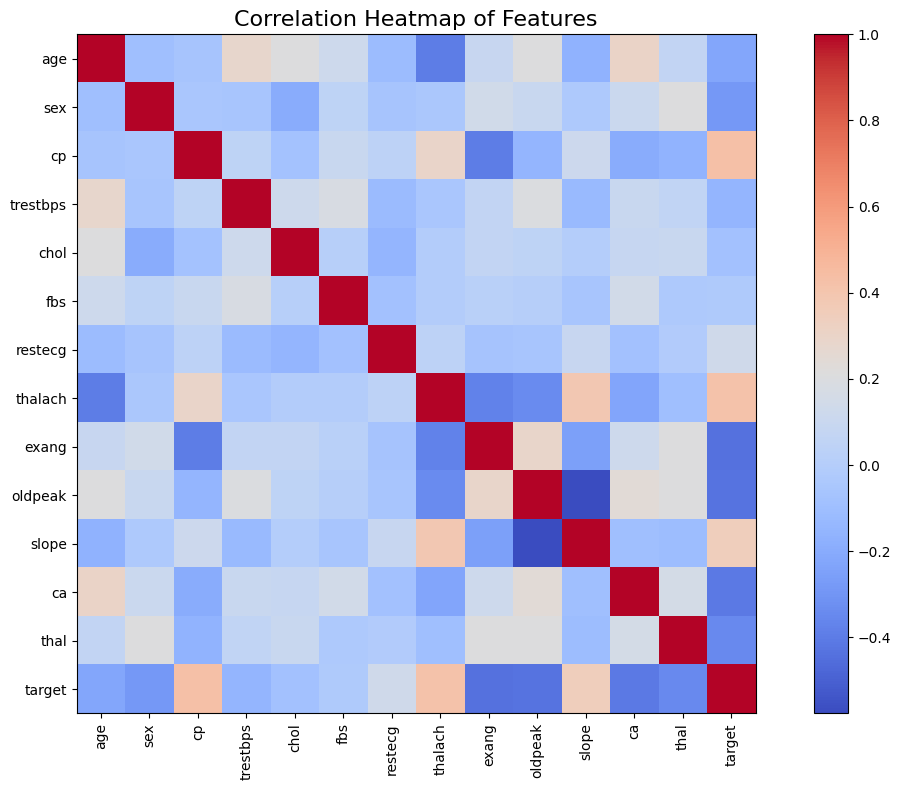

In [9]:
# Calculate the correlation matrix
correlation_matrix = preprocessed_df.corr()

# Plotting the heatmap for feature correlations
plt.figure(figsize=(12, 8))
plt.title('Correlation Heatmap of Features', fontsize=16)
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.tight_layout()
plt.show()

## Correlation Heatmap

The correlation heatmap provides a visual representation of the relationships between all numerical features in the dataset. Each square represents the correlation coefficient between a pair of features. Values closer to +1 indicate a strong positive correlation, while values closer to -1 indicate a strong negative correlation. A value of 0 means no correlation. The heatmap helps us identify redundant features and potential relationships between features that may be useful for predicting heart disease.

## Feature-Target Correlation

Next, we focus on the relationship between individual features and the target variable (heart disease presence). This step will help identify the features that are most strongly correlated with the target.

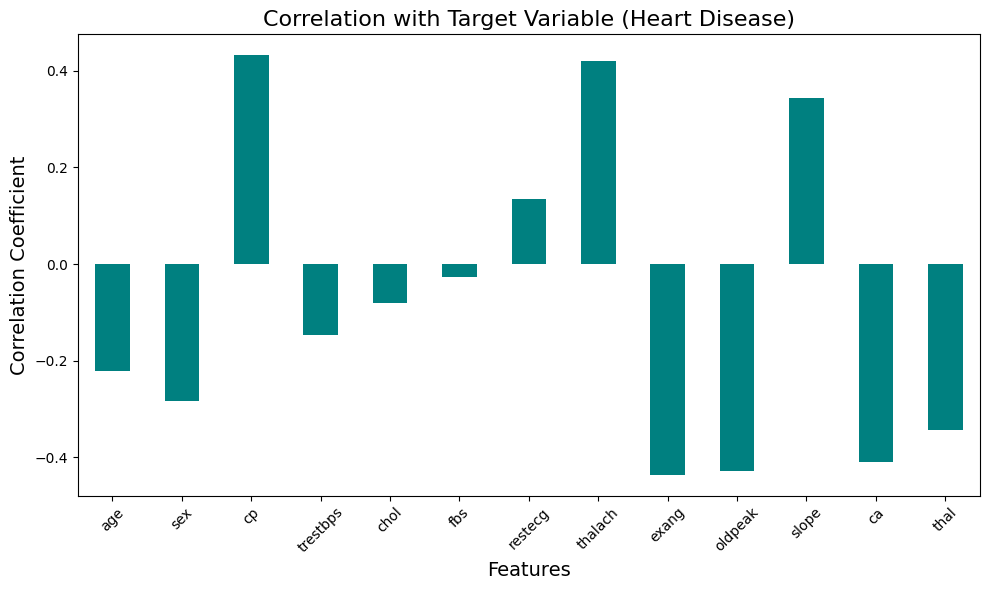

Feature-Target Correlation:
age        -0.221476
sex        -0.283609
cp          0.432080
trestbps   -0.146269
chol       -0.081437
fbs        -0.026826
restecg     0.134874
thalach     0.419955
exang      -0.435601
oldpeak    -0.429146
slope       0.343940
ca         -0.408992
thal       -0.343101
Name: target, dtype: float64


In [10]:
# Plot the correlation between each feature and the target variable
plt.figure(figsize=(10, 6))
correlation_with_target = preprocessed_df.corr()['target'].drop('target')
correlation_with_target.plot(kind='bar', color='teal', figsize=(10, 6))
plt.title('Correlation with Target Variable (Heart Disease)', fontsize=16)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xlabel('Features', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display the feature-target correlations
print("Feature-Target Correlation:")
print(correlation_with_target)

## Feature-Target Correlation

Next, we will focus on the relationship between each individual feature and the target variable (presence of heart disease). By examining how each feature correlates with the target, we can identify which features have the strongest influence on the prediction task. Features that are strongly correlated with the target are likely to be the most informative for model training.

## Feature Selection

Based on the results of the correlation analysis, we will now perform feature selection. This will involve selecting the most relevant features based on their correlation with the target variable and their importance in the prediction task.

In [11]:
# Set a correlation threshold (e.g., selecting features with correlation > 0.1 or < -0.1 with the target)
threshold = 0.1
selected_features = correlation_with_target[abs(correlation_with_target) > threshold].index.tolist()

# Display the selected features
print("Selected Features based on Correlation with Target:")
print(selected_features)

Selected Features based on Correlation with Target:
['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Feature Selection

We have selected the features that exhibit a correlation coefficient greater than 0.1 or less than -0.1 with the target variable. These features are considered significant in predicting heart disease and will be used for model training. Feature selection is an essential step to reduce the dimensionality of the data, improve model efficiency, and avoid overfitting by removing irrelevant or redundant features.

## Pairplot of Selected Features

A pairplot will help us visualize the relationships between the selected features and the target variable. This will provide insights into the distribution and potential separability of the data.

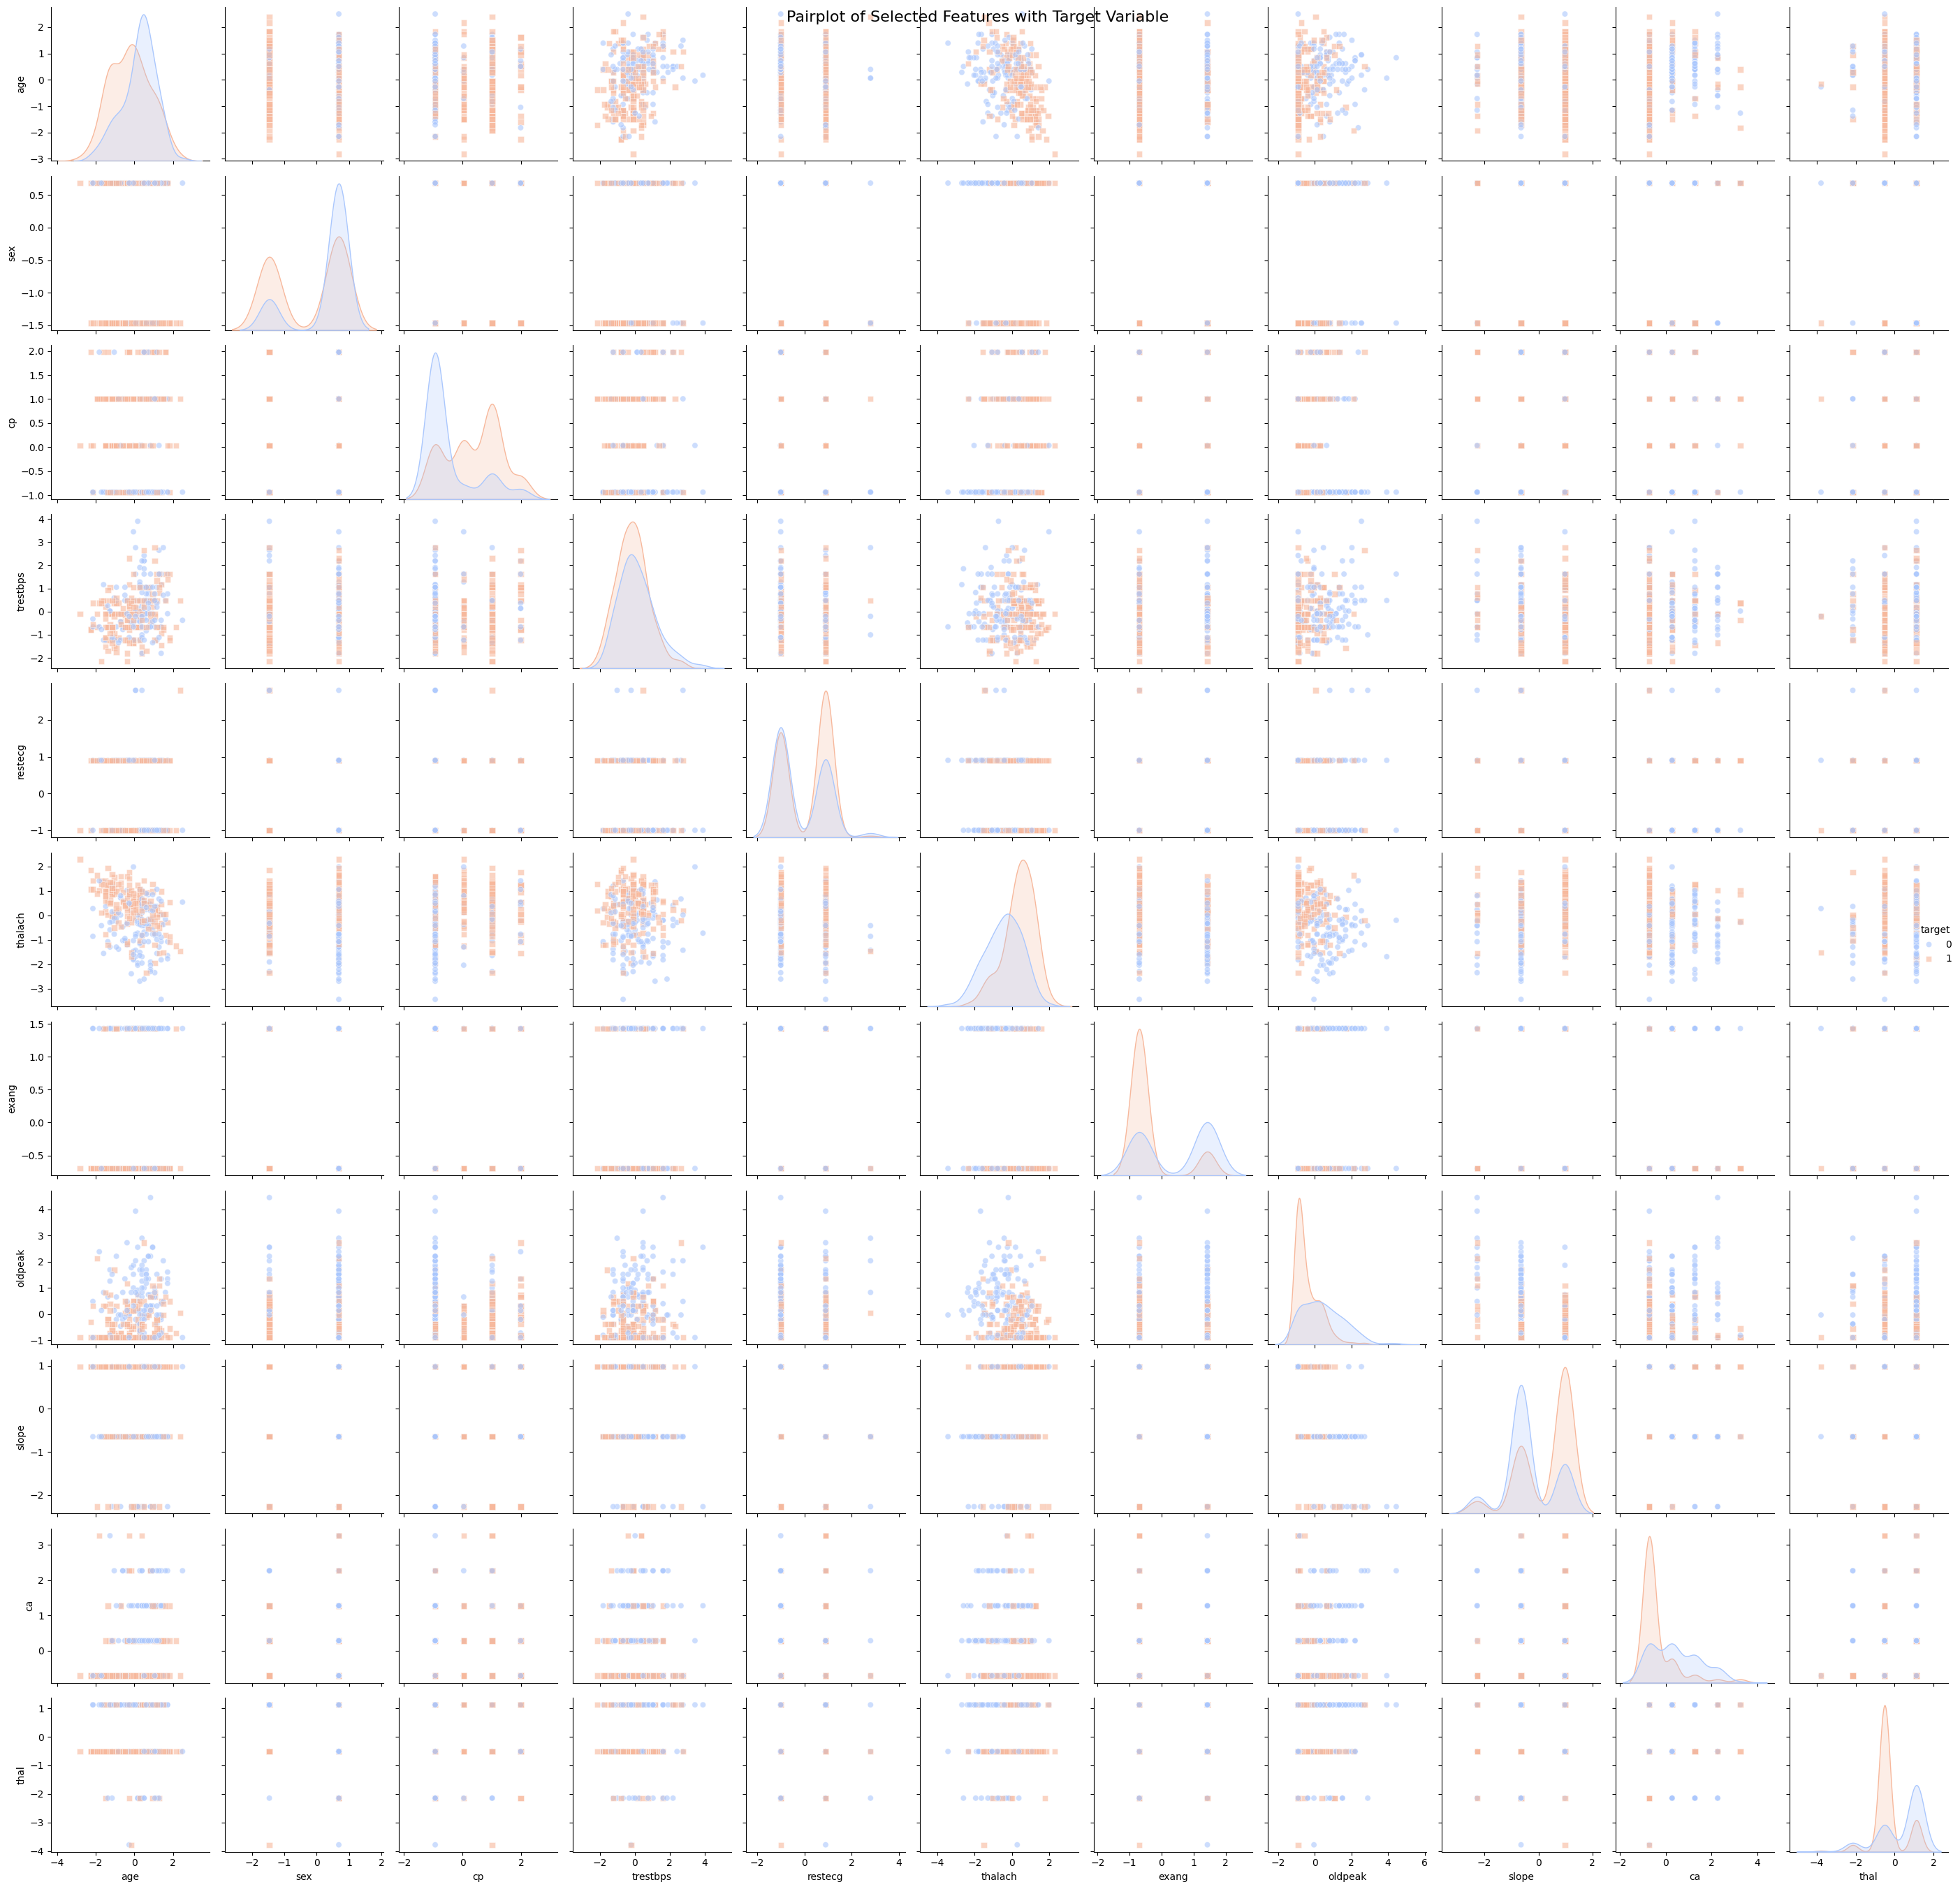

In [12]:
# Plot a pairplot for selected features
import seaborn as sns

# Filter the preprocessed dataframe to include only selected features and target
df_selected_features = preprocessed_df[selected_features + ['target']]

# Plot pairplot to visualize relationships between selected features
sns.pairplot(df_selected_features, hue='target', markers=["o", "s"], palette="coolwarm", plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Selected Features with Target Variable', fontsize=16)
plt.tight_layout()
plt.show()

## Pairplot Visualization

The pairplot provides an overview of how the selected features relate to the target variable. By visualizing the data points with respect to the target, we can assess whether the features offer clear separation between the classes (heart disease vs. no heart disease). In this visualization, the color coding indicates the target variable, with different markers representing the two classes. If the features show a clear distinction in their distributions, this suggests that they may be useful for classification tasks.

## Summary of Feature Selection

Through correlation analysis and pairplot visualization, we have identified the most relevant features for predicting heart disease. Features that show strong correlations with the target variable have been selected for model training. These features provide meaningful information that will help improve the accuracy and performance of the predictive model. In the next phase, we will use these selected features to train and evaluate machine learning models.

# Phase 4: Model Development and Evaluation

In this phase, we develop and evaluate machine learning models for heart disease prediction. We will experiment with several algorithms, including Logistic Regression, Decision Trees, and Random Forests, and evaluate their performance using multiple metrics. We will also optimize the models through hyperparameter tuning to achieve the best possible performance.

In [13]:
# Import necessary libraries for model development and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Data Splitting

We first split the dataset into features (X) and target (y), and then divide the data into training and testing sets. The training set will be used to train the models, while the test set will be used to evaluate model performance.

In [14]:
# Separate features (X) and target (y)
X = preprocessed_df[selected_features]
y = preprocessed_df['target']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"Training set shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test set shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set shape: X_train: (241, 11), y_train: (241,)
Test set shape: X_test: (61, 11), y_test: (61,)


## Logistic Regression Model

Logistic Regression is a simple yet effective model for binary classification tasks. We will first train a Logistic Regression model using the training data and evaluate its performance on the test data.

In [15]:
# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Train the model on the training set
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the Logistic Regression model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_log_reg):.4f}")

Logistic Regression Model Evaluation:
Accuracy: 0.7377
Precision: 0.6857
Recall: 0.8276
F1-Score: 0.7500
ROC AUC Score: 0.7419


## Decision Tree Model

Decision Trees are powerful classifiers that model data by splitting it into subsets based on feature values. We will now train a Decision Tree classifier and evaluate its performance.

In [16]:
# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model on the training set
dt.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt.predict(X_test)

# Evaluate the Decision Tree model
print("\nDecision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_dt):.4f}")


Decision Tree Model Evaluation:
Accuracy: 0.7049
Precision: 0.6897
Recall: 0.6897
F1-Score: 0.6897
ROC AUC Score: 0.7042


## Random Forest Model

Random Forest is an ensemble method that uses multiple decision trees to improve predictive accuracy. We will now train a Random Forest model and evaluate its performance.

In [17]:
# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Train the model on the training set
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test)

# Evaluate the Random Forest model
print("\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_rf):.4f}")


Random Forest Model Evaluation:
Accuracy: 0.8197
Precision: 0.7812
Recall: 0.8621
F1-Score: 0.8197
ROC AUC Score: 0.8217


## Model Comparison

Now that we have evaluated the Logistic Regression, Decision Tree, and Random Forest models, we will compare their performance on several evaluation metrics, including accuracy, precision, recall, F1-score, and ROC AUC. This will help us identify the most suitable model for heart disease prediction.

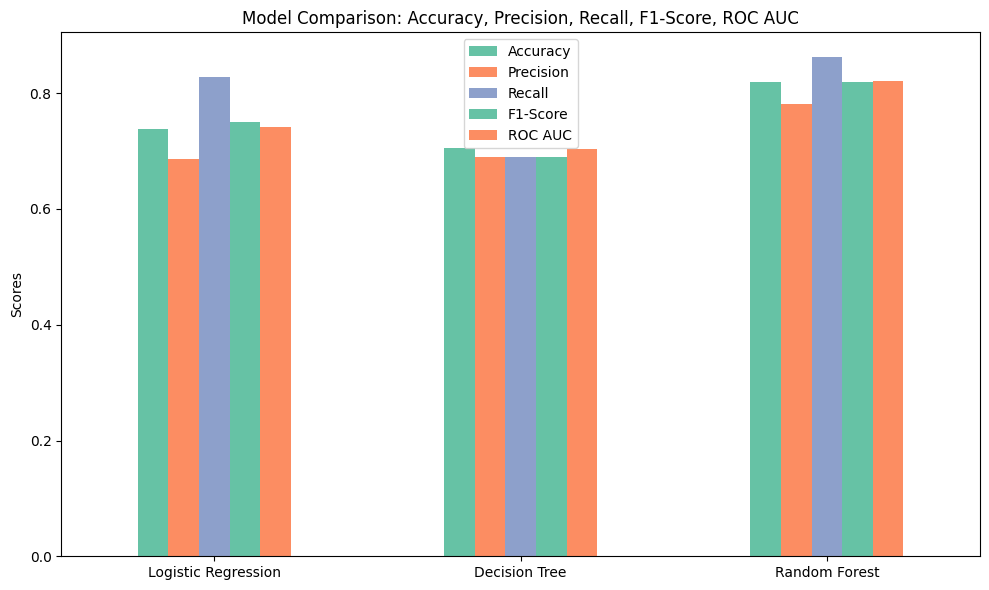

                     Accuracy  Precision    Recall  F1-Score   ROC AUC
Logistic Regression  0.737705   0.685714  0.827586  0.750000  0.741918
Decision Tree        0.704918   0.689655  0.689655  0.689655  0.704203
Random Forest        0.819672   0.781250  0.862069  0.819672  0.821659


In [27]:
# Store the evaluation results in a dictionary for easy comparison
model_comparison = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log_reg),
        "Precision": precision_score(y_test, y_pred_log_reg),
        "Recall": recall_score(y_test, y_pred_log_reg),
        "F1-Score": f1_score(y_test, y_pred_log_reg),
        "ROC AUC": roc_auc_score(y_test, y_pred_log_reg)
    },
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-Score": f1_score(y_test, y_pred_dt),
        "ROC AUC": roc_auc_score(y_test, y_pred_dt)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC AUC": roc_auc_score(y_test, y_pred_rf)
    }
}

# Convert the dictionary to a DataFrame for better visualization
model_comparison_df = pd.DataFrame(model_comparison)
model_comparison_df = model_comparison_df.T

# Display the model comparison DataFrame
import matplotlib.pyplot as plt

# Plotting the comparison results
model_comparison_df.plot(kind='bar', figsize=(10, 6), color=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title('Model Comparison: Accuracy, Precision, Recall, F1-Score, ROC AUC')
plt.ylabel('Scores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display the model comparison table
print(model_comparison_df)

## Hyperparameter Tuning

To further improve model performance, we can tune the hyperparameters of our models. Hyperparameter tuning involves selecting the optimal values for model parameters that control the training process. In this section, we will use GridSearchCV to find the best hyperparameters for our Random Forest model.

In [28]:
# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize the GridSearchCV with cross-validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Display the best parameters from GridSearchCV
print(f"Best hyperparameters for Random Forest: {grid_search.best_params_}")

# Evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

# Evaluate the tuned Random Forest model
print("\nTuned Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_best_rf):.4f}")

Best hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Tuned Random Forest Model Evaluation:
Accuracy: 0.8197
Precision: 0.7647
Recall: 0.8966
F1-Score: 0.8254
ROC AUC Score: 0.8233


# Phase 5: Hyperparameter Tuning and Final Model Selection

In this phase, we will focus on optimizing the performance of the Random Forest model through hyperparameter tuning. We will use **GridSearchCV** to search for the best combination of hyperparameters and select the model with the highest performance. After tuning, we will evaluate the final model using the test dataset and report its performance.

In [29]:
# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=2)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Display the best parameters from GridSearchCV
print(f"Best hyperparameters for Random Forest: {grid_search.best_params_}")

# Evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

# Evaluate the tuned Random Forest model
print("\nTuned Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_best_rf):.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[

## Hyperparameter Tuning with GridSearchCV

In this step, we use **GridSearchCV** to perform an exhaustive search over a specified parameter grid for the Random Forest model. The goal is to find the best combination of hyperparameters that optimizes model performance. We will evaluate multiple combinations of parameters using cross-validation to ensure the model generalizes well to unseen data. After tuning, the best model will be selected for final evaluation.


Final Model Performance:
Accuracy: 0.8361
Precision: 0.7879
Recall: 0.8966
F1-Score: 0.8387
ROC AUC Score: 0.8389


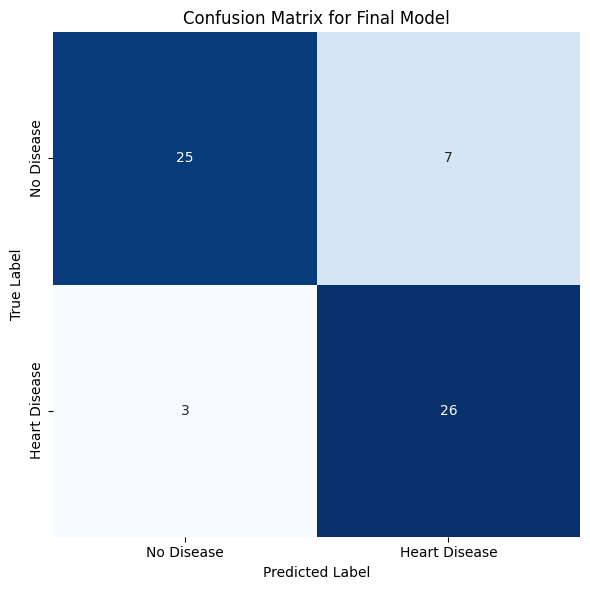

In [30]:
# Final model evaluation
print("\nFinal Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_best_rf):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['No Disease', 'Heart Disease'], yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Final Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Final Model Evaluation

After performing hyperparameter tuning using **GridSearchCV**, we now evaluate the tuned **Random Forest** model on the test dataset. The performance metrics (accuracy, precision, recall, F1-score, and ROC AUC) are displayed for the final model. Additionally, we present the **confusion matrix** to further analyze the true positives, false positives, true negatives, and false negatives of our predictions. This will help assess the model's ability to classify heart disease accurately.

## Conclusion

In this phase, we have successfully tuned the **Random Forest** model using **GridSearchCV** and evaluated its performance on the test dataset. The model's performance metrics provide insights into its ability to predict heart disease accurately. In the next phase, we will prepare the model for deployment, ensuring that it can be used for real-time prediction in a clinical setting.

# Step 1: Model Serialization

In this step, we will save the tuned Random Forest model using **joblib**. This serialized model can be loaded later for predictions without needing to retrain the model. Serialization allows us to store the model and use it in production systems or future analysis.

In [31]:
import joblib

# Save the final tuned Random Forest model
joblib.dump(best_rf, 'random_forest_model.pkl')
print("Model has been saved as 'random_forest_model.pkl'")

Model has been saved as 'random_forest_model.pkl'
